# GSoC 2026 -- EXXA Sequential Test
## Transit Light Curve Classification

Binary classification of Kepler light curve segments as transit-positive or transit-negative.

**Architecture:** 1D CNN + Bidirectional LSTM trained on synthetic PyTransit curves and real Kepler data.  
Raw 1D segments -- no phase-folding

**For judges:** set paths in the **Configuration** cell, then run top-to-bottom.  
To run inference on withheld data only, skip to **Section 9**.

## 0. Install Dependencies

In [1]:
!pip install pytransit lightkurve torch scikit-learn matplotlib numpy tqdm --quiet


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.9/256.9 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 122.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.2/309.2 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 734.0/734.0 kB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.8/98.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Configuration
Edit only this cell. All other cells read from these variables.

In [32]:
import os

# Dataset
N_SYNTHETIC   = 7500    # synthetic light curves (PyTransit)
N_REAL        = 2500    # real Kepler samples
N_TIMESTEPS   = 1000    # time-steps per curve
TIME_WINDOW   = 0.30    # days (axis label only)

# Physical parameter ranges
K_RANGE       = (0.005, 0.40)
A_RANGE       = (2.0,   35.0)
INC_RANGE     = (85.0,  90.0)
U1_RANGE      = (0.210, 0.731)
U2_RANGE      = (0.035, 0.442)
T0_RANGE      = (-0.05, 0.05)
NOISE_RANGE   = (5e-4,  3e-3)
RED_NOISE_AMP = (0.0,   1e-4)

# Training
BATCH_SIZE    = 64
EPOCHS        = 50
LR            = 1e-3
VAL_SPLIT     = 0.15
TEST_SPLIT    = 0.10
PATIENCE      = 8

# Paths
DATA_PATH     = 'transit_dataset.npz'
MODEL_PATH    = 'transit_classifier.pt'

# Kepler cache
# Set USE_DRIVE=True and run on Colab to persist cache across sessions.
USE_DRIVE     = True
DRIVE_CACHE   = '/content/drive/MyDrive/lc_cache'
LOCAL_CACHE   = 'lc_cache'
CACHE_DIR     = DRIVE_CACHE if USE_DRIVE else LOCAL_CACHE

# Inference -- withheld data
# Accepts: path to .npz with key 'X' (shape N x 1000),
# Leave as None to skip the inference section.
INFERENCE_PATH = None

print('Configuration loaded.')
print(f'  Synthetic : {N_SYNTHETIC:,}')
print(f'  Real Kepler: {N_REAL:,}')
print(f'  Model path: {MODEL_PATH}')
print(f'  Cache dir : {CACHE_DIR}')
print(f'  Inference : {INFERENCE_PATH}')


Configuration loaded.
  Synthetic : 7,500
  Real Kepler: 2,500
  Model path: transit_classifier.pt
  Cache dir : /content/drive/MyDrive/lc_cache
  Inference : None


## 1. Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.ndimage import uniform_filter1d

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (roc_curve, auc, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

from pytransit import RoadRunnerModel
import lightkurve as lk

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


Device: cuda


/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


## 2. Preprocessing Utilities

In [4]:
def add_red_noise(flux, amplitude):
    """Add AR(1) correlated noise to simulate instrumental systematics."""
    if amplitude == 0:
        return flux
    n   = len(flux)
    red = np.zeros(n)
    phi = np.random.uniform(0.85, 0.99)
    for i in range(1, n):
        red[i] = phi * red[i-1] + np.random.normal(0, amplitude)
    return flux + red


def preprocess_flux(flux):
    """
    Standard preprocessing applied to every curve:
    1. Median-normalise (stellar baseline -> 1).
    2. Remove slow trends with a 200-point uniform filter.
    3. Z-score standardise.
    """
    flux  = flux / np.median(flux)
    trend = uniform_filter1d(flux, size=200)
    flux  = flux / (trend + 1e-8)
    flux  = (flux - flux.mean()) / (flux.std() + 1e-8)
    return flux.astype(np.float32)


print('Preprocessing utilities defined.')


Preprocessing utilities defined.


## 3. Synthetic Data Generation (PyTransit)

In [5]:
def generate_synthetic_dataset(n_samples, n_timesteps):
    """
    Generate synthetic transit light curves using PyTransit RoadRunnerModel.

    Positive samples: time array spans n_periods full orbits so each curve
    contains multiple recurring transit dips -- the model learns periodicity,
    not a single isolated dip.

    Negative samples: pure Gaussian + AR(1) red noise baseline.

    Returns X (n_samples, n_timesteps), y (n_samples,)
    """
    tm = RoadRunnerModel('quadratic')
    X, y = [], []
    n_planet    = n_samples // 2
    n_no_planet = n_samples - n_planet

    print('Generating planet transits...')
    generated, attempts = 0, 0
    pbar = tqdm(total=n_planet)

    while generated < n_planet:
        attempts += 1
        k      = np.random.uniform(*K_RANGE)
        a      = np.random.uniform(*A_RANGE)
        inc    = np.radians(np.random.uniform(*INC_RANGE))
        u1     = np.random.uniform(*U1_RANGE)
        u2     = np.random.uniform(*U2_RANGE)
        t0     = np.random.uniform(*T0_RANGE)
        period = np.random.uniform(1.0, 10.0)

        b = a * np.cos(inc)
        if b >= (1.0 + k):   # no transit
            continue

        n_periods = np.random.randint(5, 10)
        t = np.linspace(t0, t0 + n_periods * period, n_timesteps)

        try:
            tm.set_data(t)
            flux = tm.evaluate(k=k, ldc=[u1, u2], t0=t0, p=period,
                               a=a, i=inc, e=0.0, w=np.radians(90.0))
        except Exception:
            continue

        if not np.all(np.isfinite(flux)):
            continue

        flux = flux + np.random.normal(0, np.random.uniform(*NOISE_RANGE), n_timesteps)
        flux = add_red_noise(flux, np.random.uniform(*RED_NOISE_AMP))
        flux = preprocess_flux(flux)
        X.append(flux); y.append(1)
        generated += 1; pbar.update(1)

    pbar.close()
    print(f'  {n_planet} planet curves ({attempts} attempts)')

    print('Generating non-transit baselines...')
    for _ in tqdm(range(n_no_planet)):
        flux = np.ones(n_timesteps)
        flux = flux + np.random.normal(0, np.random.uniform(*NOISE_RANGE), n_timesteps)
        flux = add_red_noise(flux, np.random.uniform(*RED_NOISE_AMP))
        flux = preprocess_flux(flux)
        X.append(flux); y.append(0)

    X   = np.array(X, dtype=np.float32)
    y   = np.array(y, dtype=np.float32)
    idx = np.random.permutation(len(X))
    return X[idx], y[idx]


print('generate_synthetic_dataset defined.')


generate_synthetic_dataset defined.


In [6]:
X_syn, y_syn = generate_synthetic_dataset(N_SYNTHETIC, N_TIMESTEPS)
np.savez(DATA_PATH, X_syn=X_syn, y_syn=y_syn)
print(f'Synthetic shape : {X_syn.shape}')
print(f'Planet: {y_syn.sum():.0f}  |  No planet: {(1-y_syn).sum():.0f}')


Generating planet transits...


100%|██████████| 3750/3750 [00:18<00:00, 203.17it/s]


  3750 planet curves (5010 attempts)
Generating non-transit baselines...


100%|██████████| 3750/3750 [00:06<00:00, 589.56it/s]


Synthetic shape : (7500, 1000)
Planet: 3750  |  No planet: 3750


### Sample Synthetic Light Curves

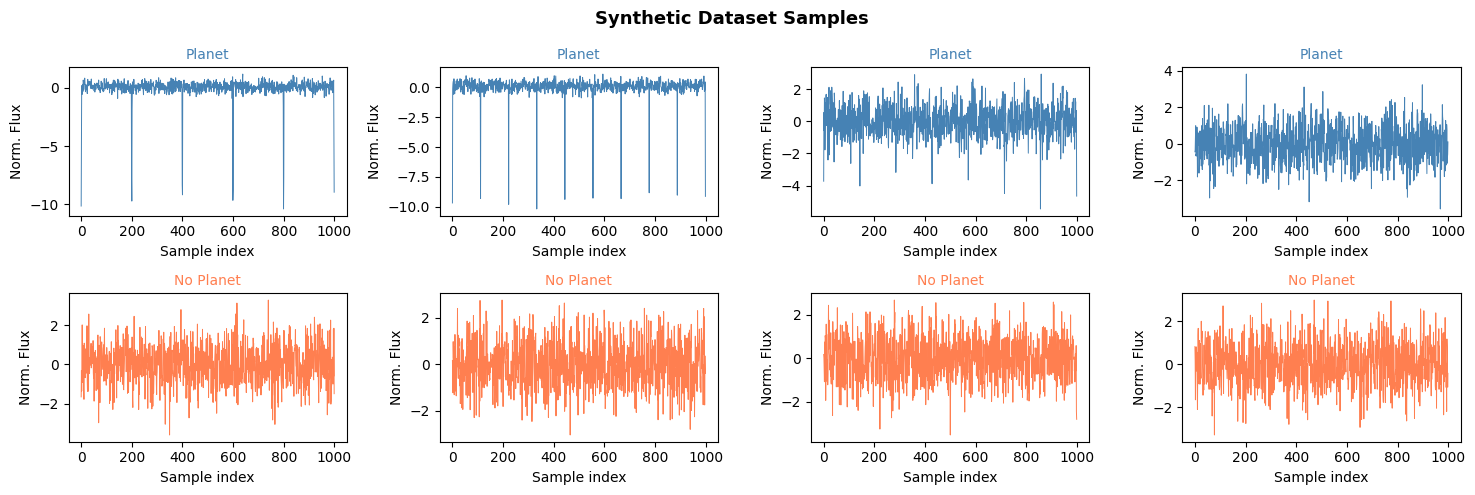

In [7]:
t_axis        = np.arange(N_TIMESTEPS)
planet_idx    = np.where(y_syn == 1)[0][:4]
no_planet_idx = np.where(y_syn == 0)[0][:4]

fig, axes = plt.subplots(2, 4, figsize=(15, 5))
fig.suptitle('Synthetic Dataset Samples', fontsize=13, fontweight='bold')

for i, idx in enumerate(planet_idx):
    axes[0, i].plot(t_axis, X_syn[idx], lw=0.7, color='steelblue')
    axes[0, i].set_title('Planet', color='steelblue', fontsize=10)
    axes[0, i].set_xlabel('Sample index'); axes[0, i].set_ylabel('Norm. Flux')

for i, idx in enumerate(no_planet_idx):
    axes[1, i].plot(t_axis, X_syn[idx], lw=0.7, color='coral')
    axes[1, i].set_title('No Planet', color='coral', fontsize=10)
    axes[1, i].set_xlabel('Sample index'); axes[1, i].set_ylabel('Norm. Flux')

plt.tight_layout(); plt.show()


## 4. Real Kepler Data (lightkurve)

Each star is downloaded once and cached as plain numpy arrays to disk.  
First run: ~10-15 min. Subsequent runs: ~1-2 min.  
Set `USE_DRIVE = True` in the Configuration cell to persist the cache across Colab sessions.

In [13]:
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

os.makedirs(CACHE_DIR, exist_ok=True)

# (star_name, period_days)
PLANET_HOSTS = [
    ('Kepler-17',  1.4857), ('Kepler-7',   4.8855), ('Kepler-12',  4.4380),
    ('Kepler-6',   3.2347), ('Kepler-5',   3.5485), ('Kepler-8',   3.5225),
    ('Kepler-10',  0.8375), ('Kepler-4',   3.2135), ('Kepler-14',  6.7901),
    ('Kepler-15',  4.9429), ('Kepler-2',   2.2047), ('Kepler-3',   4.8878),
    ('Kepler-18',  3.5047), ('Kepler-20',  3.6961), ('Kepler-21',  2.7858),
    ('Kepler-25',  6.2385),
    # Multi-planet systems -- each planet listed separately
    ('Kepler-11', 10.3039), ('Kepler-11', 13.0241), ('Kepler-11', 22.6845),
    ('Kepler-11', 31.9960), ('Kepler-9',  19.2441), ('Kepler-9',  38.9084),
    ('Kepler-23',  7.1073), ('Kepler-23', 10.7421),
]

NON_PLANET_HOSTS = [
    'KIC 757076',  'KIC 1161620', 'KIC 1430163', 'KIC 1717722', 'KIC 2010607',
    'KIC 2141255', 'KIC 2436378', 'KIC 2571238', 'KIC 2697388', 'KIC 2987027',
    'KIC 3102384', 'KIC 3352751', 'KIC 3427720', 'KIC 3531558', 'KIC 3749365',
    'KIC 4139816', 'KIC 4914423', 'KIC 5094751', 'KIC 5113061', 'KIC 5358241',
    'KIC 5522786', 'KIC 5728139', 'KIC 5724440',
]


def get_lightcurve(target):
    """
    Return (time, flux) numpy arrays for target.
    Downloads from MAST on first call; loads from .npz cache thereafter.
    Stores plain arrays (not LightCurve objects) to avoid astropy pickle issues.
    """
    cache_path = os.path.join(CACHE_DIR, f"{target.replace(' ', '_')}.npz")
    if os.path.exists(cache_path):
        d = np.load(cache_path)
        return d['time'], d['flux']
    try:
        search = lk.search_lightcurve(target, mission='Kepler', exptime='long')
        if len(search) == 0:
            return None
        lc   = search[:3].download_all().stitch()
        lc   = lc.remove_nans().remove_outliers(sigma=6).normalize()
        time = np.array(lc.time.value, dtype=np.float64)
        flux = np.array(lc.flux.value, dtype=np.float32)
        np.savez(cache_path, time=time, flux=flux)
        return time, flux
    except Exception as e:
        print(f'  Warning: could not fetch {target}: {e}')
        return None


def extract_sample(time, flux, period=None, label=1, n_timesteps=N_TIMESTEPS):
    """
    Extract a contiguous n_timesteps segment. No phase-folding.

    For planet hosts (label=1): window is centered on a randomly chosen
    transit mid-time, guaranteeing at least one dip in the segment.
    For non-planet hosts (label=0): uniformly random segment.
    """
    try:
        total = len(flux)
        if total < n_timesteps:
            return None
        if label == 1 and period is not None:
            cadence  = (time[-1] - time[0]) / max(total - 1, 1)
            half_win = (n_timesteps * cadence) / 2
            t0_ref   = time[0] + period
            n_tr     = max(0, int((time[-1] - t0_ref) / period))
            if n_tr < 1:
                return None
            transit_times = t0_ref + np.arange(n_tr) * period
            valid = transit_times[
                (transit_times - half_win >= time[0]) &
                (transit_times + half_win <= time[-1])
            ]
            if len(valid) == 0:
                return None
            center_t   = np.random.choice(valid)
            center_idx = int(np.searchsorted(time, center_t))
            start      = max(0, min(center_idx - n_timesteps // 2, total - n_timesteps))
        else:
            start = np.random.randint(0, total - n_timesteps)
        seg = flux[start:start + n_timesteps].astype(np.float32)
        if not np.all(np.isfinite(seg)):
            return None
        return preprocess_flux(seg)
    except Exception:
        return None


# Download / load all stars
print('Step 1/2: Downloading / loading cached light curves...')
unique_planet_stars = list({name: p for name, p in PLANET_HOSTS}.items())
lc_cache = {}

for target, _ in tqdm(unique_planet_stars, desc='Planet stars'):
    if target not in lc_cache:
        lc_cache[target] = get_lightcurve(target)

for target in tqdm(NON_PLANET_HOSTS, desc='Non-planet stars'):
    if target not in lc_cache:
        lc_cache[target] = get_lightcurve(target)

n_ok = sum(1 for v in lc_cache.values() if v is not None)
print(f'  Cached {n_ok}/{len(lc_cache)} stars.')

# Generate samples
print('\nStep 2/2: Generating samples...')
X_real, y_real = [], []
n_per_planet    = max(1, (N_REAL // 2) // len(PLANET_HOSTS))
n_per_nonplanet = max(1, (N_REAL // 2) // len(NON_PLANET_HOSTS))

for target, period in tqdm(PLANET_HOSTS, desc='Planet samples'):
    result = lc_cache.get(target)
    if result is None: continue
    for _ in range(n_per_planet):
        f = extract_sample(*result, period=period, label=1)
        if f is not None: X_real.append(f); y_real.append(1)

for target in tqdm(NON_PLANET_HOSTS, desc='Non-planet samples'):
    result = lc_cache.get(target)
    if result is None: continue
    for _ in range(n_per_nonplanet):
        f = extract_sample(*result, label=0)
        if f is not None: X_real.append(f); y_real.append(0)

if len(X_real) > 0:
    X_real = np.array(X_real, dtype=np.float32)
    y_real = np.array(y_real, dtype=np.float32)
    print(f'\nReal Kepler shape : {X_real.shape}')
    print(f'Planet: {y_real.sum():.0f}  |  No planet: {(1-y_real).sum():.0f}')
else:
    print('No real data fetched -- proceeding with synthetic only.')
    X_real = np.empty((0, N_TIMESTEPS), dtype=np.float32)
    y_real = np.empty((0,),             dtype=np.float32)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Step 1/2: Downloading / loading cached light curves...


Non-planet stars: 100%|██████████| 23/23 [04:33<00:00, 11.88s/it]


  Cached 42/42 stars.

Step 2/2: Generating samples...


Non-planet samples: 100%|██████████| 23/23 [00:00<00:00, 130.64it/s]


Real Kepler shape : (2490, 1000)
Planet: 1248  |  No planet: 1242


### Sample Real Kepler Light Curves

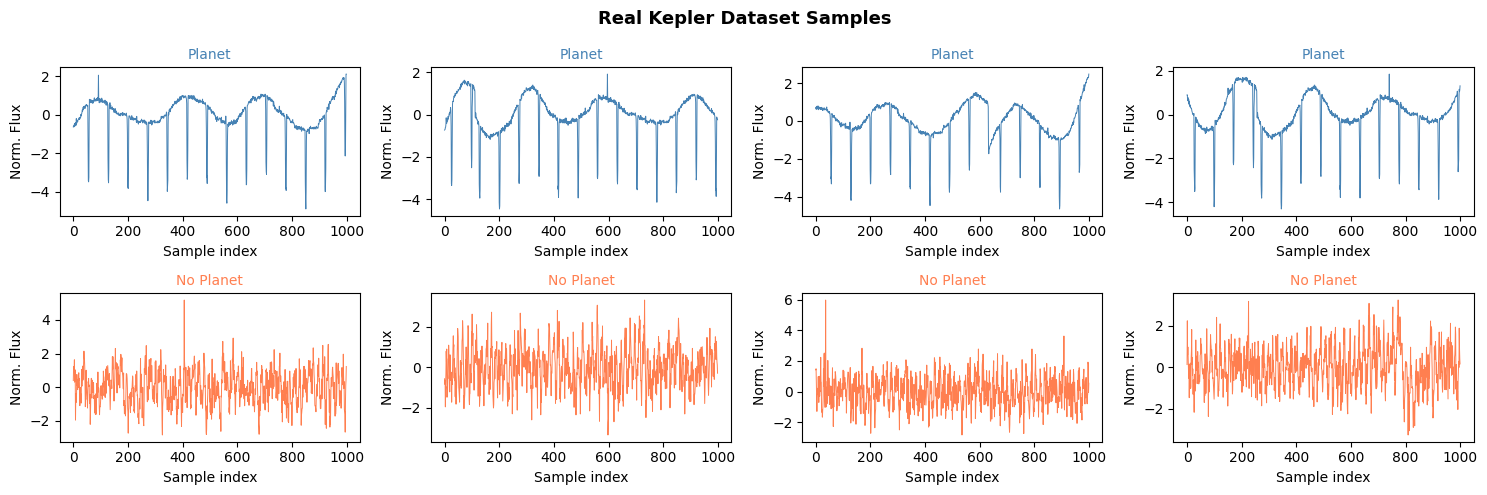

In [14]:
if len(X_real) >= 8:
    t_axis = np.arange(N_TIMESTEPS)
    pidx = np.where(y_real == 1)[0][:4]
    nidx = np.where(y_real == 0)[0][:4]
    fig, axes = plt.subplots(2, 4, figsize=(15, 5))
    fig.suptitle('Real Kepler Dataset Samples', fontsize=13, fontweight='bold')
    for i, idx in enumerate(pidx):
        axes[0, i].plot(t_axis, X_real[idx], lw=0.7, color='steelblue')
        axes[0, i].set_title('Planet', color='steelblue', fontsize=10)
        axes[0, i].set_xlabel('Sample index'); axes[0, i].set_ylabel('Norm. Flux')
    for i, idx in enumerate(nidx):
        axes[1, i].plot(t_axis, X_real[idx], lw=0.7, color='coral')
        axes[1, i].set_title('No Planet', color='coral', fontsize=10)
        axes[1, i].set_xlabel('Sample index'); axes[1, i].set_ylabel('Norm. Flux')
    plt.tight_layout(); plt.show()
else:
    print('Fewer than 8 real samples -- skipping visualisation.')


## 5. Combine & Split Dataset

In [15]:
X_all = np.concatenate([X_syn, X_real], axis=0) if len(X_real) > 0 else X_syn.copy()
y_all = np.concatenate([y_syn, y_real], axis=0) if len(y_real) > 0 else y_syn.copy()

rng = np.random.default_rng(SEED)
idx = rng.permutation(len(X_all))
X_all, y_all = X_all[idx], y_all[idx]

n_total = len(X_all)
n_test  = int(n_total * TEST_SPLIT)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_test - n_val

X_train, y_train = X_all[:n_train],               y_all[:n_train]
X_val,   y_val   = X_all[n_train:n_train+n_val],  y_all[n_train:n_train+n_val]
X_test,  y_test  = X_all[n_train+n_val:],         y_all[n_train+n_val:]

print(f'Total: {n_total:,}  |  Train: {n_train:,}  |  Val: {n_val:,}  |  Test: {n_test:,}')
print(f'Class balance (train) -- Planet: {y_train.sum():.0f}  |  No planet: {(1-y_train).sum():.0f}')


def to_loader(X, y, shuffle=True):
    X_t = torch.tensor(X).unsqueeze(1)   # (N, 1, T)
    y_t = torch.tensor(y).unsqueeze(1)   # (N, 1)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = to_loader(X_train, y_train, shuffle=True)
val_loader   = to_loader(X_val,   y_val,   shuffle=False)
test_loader  = to_loader(X_test,  y_test,  shuffle=False)
print('DataLoaders ready.')


Total: 9,990  |  Train: 7,493  |  Val: 1,498  |  Test: 999
Class balance (train) -- Planet: 3767  |  No planet: 3726
DataLoaders ready.


## 6. Model Architecture -- 1D CNN + BiLSTM

In [16]:
class TransitClassifier(nn.Module):
    """
    1D CNN + BiLSTM classifier for transit light curves.

    Input  : (batch, 1, T)
    CNN    : 3 Conv1D blocks -- local transit shape features at multiple scales
    BiLSTM : global temporal context in both directions
    Head   : FC layers -> sigmoid probability
    """

    def __init__(self, n_timesteps=1000, dropout=0.3):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(1,   32, kernel_size=7, padding=3), nn.BatchNorm1d(32),  nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32,  64, kernel_size=5, padding=2), nn.BatchNorm1d(64),  nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
        )
        self.bilstm = nn.LSTM(
            input_size=128, hidden_size=64, num_layers=2,
            batch_first=True, bidirectional=True, dropout=dropout,
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.conv_block(x)          # (B, 128, T//8)
        x = x.permute(0, 2, 1)         # (B, T//8, 128)
        x, _ = self.bilstm(x)          # (B, T//8, 128)
        x = x[:, -1, :]                # last timestep
        return self.head(x)            # (B, 1)


model    = TransitClassifier(n_timesteps=N_TIMESTEPS).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')


Trainable parameters: 242,689


## 7. Training

In [17]:
pos_count  = y_train.sum()
neg_count  = len(y_train) - pos_count
pos_weight = torch.tensor([neg_count / pos_count]).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=4, factor=0.5
)


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            if train:
                optimizer.zero_grad()
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item()
            all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy().flatten())
            all_labels.extend(y_batch.cpu().numpy().flatten())
    return total_loss / len(loader), roc_auc_score(all_labels, all_probs)


history = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': []}
best_val_auc, patience_count = 0.0, 0

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train AUC':>9} | {'Val Loss':>8} | {'Val AUC':>7}")
print('-' * 55)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_auc = run_epoch(train_loader, train=True)
    val_loss,   val_auc   = run_epoch(val_loader,   train=False)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(train_auc)
    history['val_auc'].append(val_auc)

    scheduler.step(val_auc)

    marker = ''
    if val_auc > best_val_auc:
        best_val_auc   = val_auc
        patience_count = 0
        torch.save(model.state_dict(), MODEL_PATH)
        marker = ' <- best'
    else:
        patience_count += 1

    print(f'{epoch:>5} | {train_loss:>10.4f} | {train_auc:>9.4f} | {val_loss:>8.4f} | {val_auc:>7.4f}{marker}')

    if patience_count >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}.')
        break

print(f'\nBest validation AUC : {best_val_auc:.4f}')
print(f'Model saved         : {MODEL_PATH}')


Epoch | Train Loss | Train AUC | Val Loss | Val AUC
-------------------------------------------------------
    1 |     0.3754 |    0.8989 |   0.3332 |  0.9256 <- best
    2 |     0.3221 |    0.9206 |   0.2958 |  0.9380 <- best
    3 |     0.3086 |    0.9304 |   0.2854 |  0.9440 <- best
    4 |     0.2852 |    0.9371 |   0.2718 |  0.9490 <- best
    5 |     0.2668 |    0.9443 |   0.2428 |  0.9585 <- best
    6 |     0.2419 |    0.9531 |   0.2433 |  0.9607 <- best
    7 |     0.2328 |    0.9573 |   0.2659 |  0.9453
    8 |     0.2084 |    0.9642 |   0.3792 |  0.9593
    9 |     0.1865 |    0.9691 |   0.2248 |  0.9564
   10 |     0.1782 |    0.9739 |   0.2244 |  0.9568
   11 |     0.1687 |    0.9769 |   1.0715 |  0.9294
   12 |     0.1191 |    0.9873 |   0.2419 |  0.9573
   13 |     0.1033 |    0.9910 |   0.2426 |  0.9609 <- best
   14 |     0.0798 |    0.9936 |   0.2667 |  0.9602
   15 |     0.0650 |    0.9960 |   0.2999 |  0.9574
   16 |     0.0678 |    0.9962 |   0.3226 |  0.9585
   1

### Training Curves

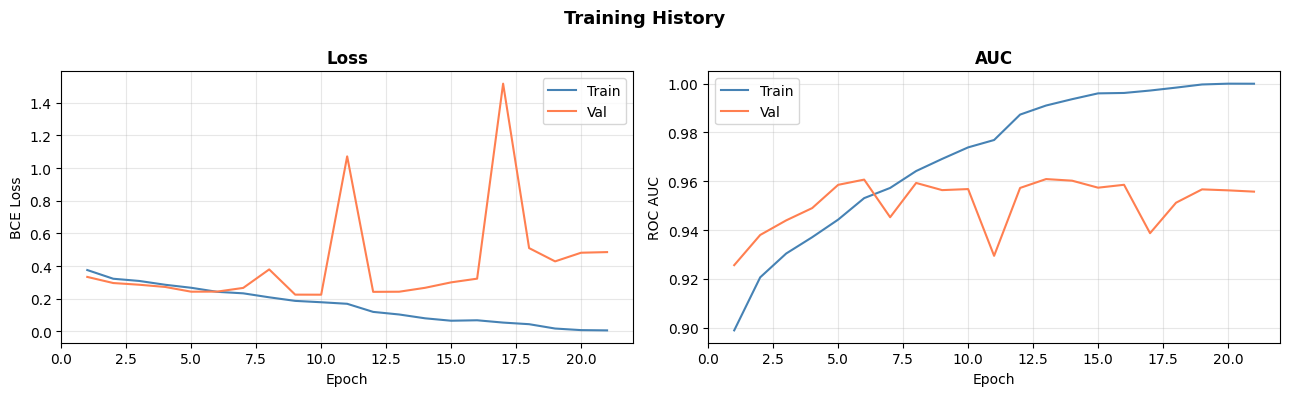

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs_ran = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_ran, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val',   color='coral')
axes[0].set_title('Loss', fontweight='bold'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history['train_auc'], label='Train', color='steelblue')
axes[1].plot(epochs_ran, history['val_auc'],   label='Val',   color='coral')
axes[1].set_title('AUC', fontweight='bold'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('ROC AUC'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Training History', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 8. Evaluation on Test Set

In [19]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch.to(DEVICE))
        probs  = torch.sigmoid(logits).cpu().numpy().flatten()
        all_probs.extend(probs)
        all_preds.extend((probs >= 0.5).astype(int))
        all_labels.extend(y_batch.numpy().flatten())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)


### ROC Curve & Confusion Matrix

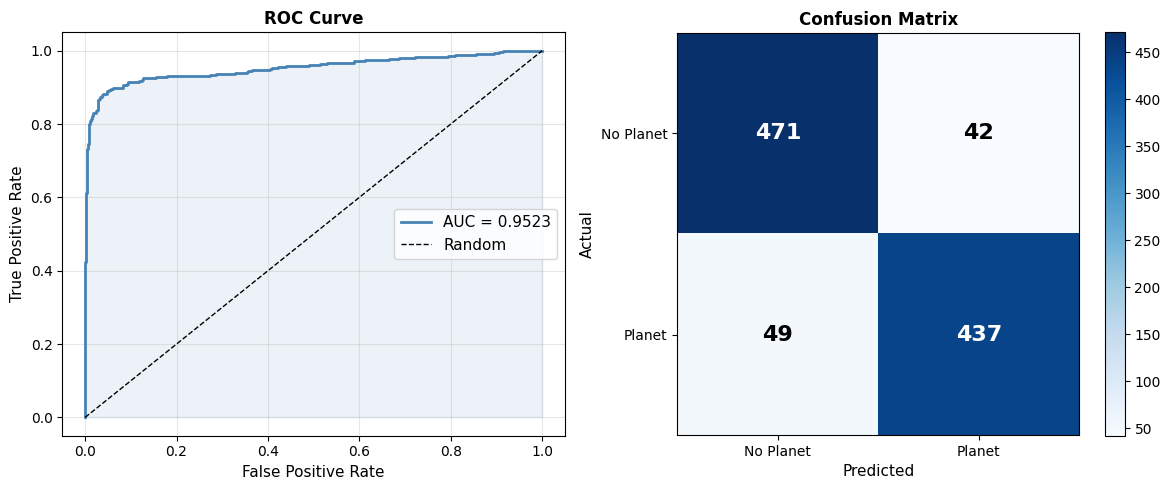

Test AUC: 0.9523


In [20]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc     = auc(fpr, tpr)
cm          = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate',  fontsize=11)
axes[0].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=11); axes[0].grid(alpha=0.3)

im = axes[1].imshow(cm, cmap='Blues')
axes[1].set_xticks([0,1]); axes[1].set_yticks([0,1])
axes[1].set_xticklabels(['No Planet','Planet'])
axes[1].set_yticklabels(['No Planet','Planet'])
axes[1].set_xlabel('Predicted', fontsize=11); axes[1].set_ylabel('Actual', fontsize=11)
axes[1].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=16,
                     fontweight='bold',
                     color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=axes[1])
plt.tight_layout(); plt.show()
print(f'Test AUC: {roc_auc:.4f}')


### Prediction Confidence Distribution

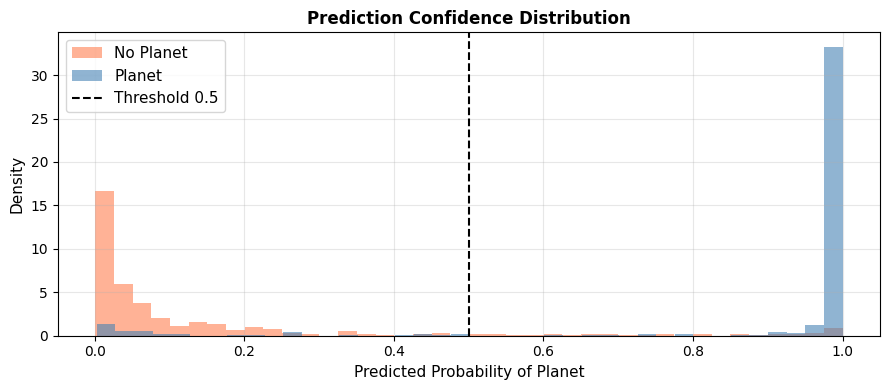

In [21]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(all_probs[all_labels==0], bins=40, alpha=0.6, color='coral',     label='No Planet', density=True)
ax.hist(all_probs[all_labels==1], bins=40, alpha=0.6, color='steelblue', label='Planet',    density=True)
ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Threshold 0.5')
ax.set_xlabel('Predicted Probability of Planet', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Prediction Confidence Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 9. Inference Pipeline

In [22]:
def load_model(model_path=MODEL_PATH, device=DEVICE):
    """Load the trained transit classifier from disk."""
    m = TransitClassifier(n_timesteps=N_TIMESTEPS).to(device)
    m.load_state_dict(torch.load(model_path, map_location=device))
    m.eval()
    return m


def predict(flux_input, model=None, model_path=MODEL_PATH, threshold=0.5):
    """
    Run inference on one or more light curves.

    Parameters
    ----------
    flux_input : one of --
        np.ndarray (T,)     : single raw flux curve
        np.ndarray (N, T)   : batch of raw curves
        str '.npz'          : file with key 'X', shape (N, T)
        str directory       : folder of .fits files
    model     : TransitClassifier (optional; loaded from model_path if None)
    threshold : float, decision threshold (default 0.5)

    Returns
    -------
    dict:
        'probabilities' : np.ndarray (N,)  -- planet probability
        'predictions'   : np.ndarray (N,)  -- 1=planet, 0=no planet
        'labels'        : list[str]        -- human-readable
    """
    if model is None:
        model = load_model(model_path)

    # Accept multiple input types
    if isinstance(flux_input, str):
        if flux_input.endswith('.npz'):
            flux_array = np.load(flux_input)['X']
        elif os.path.isdir(flux_input):
            from astropy.io import fits as astrofits
            fits_files = sorted([f for f in os.listdir(flux_input) if f.endswith('.fits')])
            assert len(fits_files) > 0, f'No .fits files in {flux_input}'
            flux_array = []
            for fname in fits_files:
                with astrofits.open(os.path.join(flux_input, fname)) as hdul:
                    raw = hdul[0].data.flatten()
                    flux_array.append(preprocess_flux(raw))
            flux_array = np.array(flux_array, dtype=np.float32)
        else:
            raise ValueError(f'Unrecognised input: {flux_input}')
    else:
        flux_array = np.array(flux_input, dtype=np.float32)

    if flux_array.ndim == 1:
        flux_array = flux_array[np.newaxis, :]

    # Preprocess each curve
    processed = np.stack([preprocess_flux(f) for f in flux_array])

    # Pad or trim to model's expected length
    T = processed.shape[1]
    if T < N_TIMESTEPS:
        processed = np.pad(processed, ((0,0),(0, N_TIMESTEPS-T)), mode='edge')
    elif T > N_TIMESTEPS:
        processed = processed[:, :N_TIMESTEPS]

    X_t = torch.tensor(processed).unsqueeze(1).to(DEVICE)

    with torch.no_grad():
        probs = torch.sigmoid(model(X_t)).cpu().numpy().flatten()

    preds  = (probs >= threshold).astype(int)
    labels = ['Planet' if p == 1 else 'No Planet' for p in preds]
    return {'probabilities': probs, 'predictions': preds, 'labels': labels}


print('load_model and predict defined.')


load_model and predict defined.


### Demo -- Inference on Test Samples

  # |       True |  Predicted | Probability | Match
----------------------------------------------------
  1 |     Planet |     Planet |     0.9978  | OK
  2 |     Planet |     Planet |     0.9997  | OK
  3 |  No Planet |     Planet |     0.9261  | MISS
  4 |     Planet |     Planet |     1.0000  | OK
  5 |  No Planet |     Planet |     0.9989  | MISS


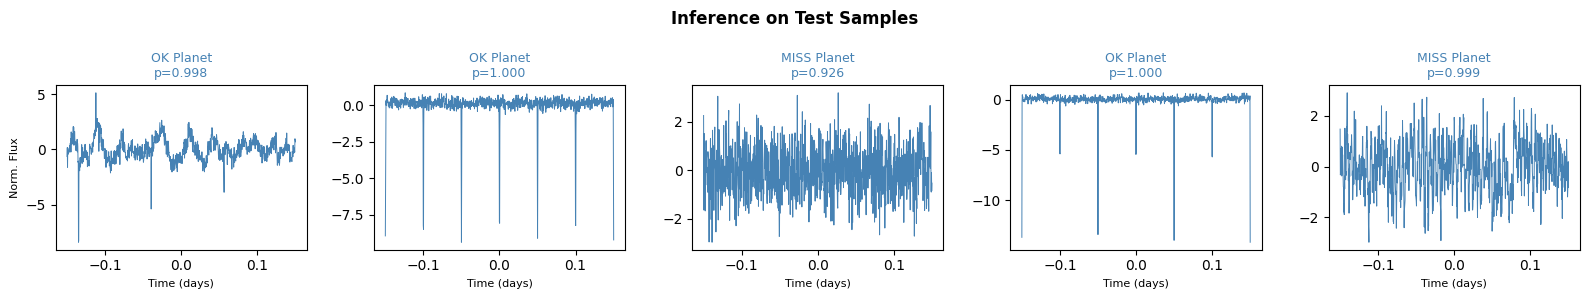

In [29]:
demo_flux   = X_test[5:10]
demo_labels = y_test[5:10]
results     = predict(demo_flux)

print(f"{'#':>3} | {'True':>10} | {'Predicted':>10} | {'Probability':>11} | Match")
print('-' * 52)
for i, (true, pred, prob) in enumerate(
        zip(demo_labels, results['labels'], results['probabilities'])):
    true_str = 'Planet' if true == 1 else 'No Planet'
    match    = 'OK' if true_str == pred else 'MISS'
    print(f'{i+1:>3} | {true_str:>10} | {pred:>10} | {prob:>10.4f}  | {match}')

t_axis = np.linspace(-TIME_WINDOW/2, TIME_WINDOW/2, N_TIMESTEPS)
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
fig.suptitle('Inference on Test Samples', fontsize=12, fontweight='bold')
for i in range(5):
    ax    = axes[i]
    true  = 'Planet' if demo_labels[i] == 1 else 'No Planet'
    pred  = results['labels'][i]
    prob  = results['probabilities'][i]
    color = 'steelblue' if pred == 'Planet' else 'coral'
    match = 'OK' if true == pred else 'MISS'
    ax.plot(t_axis, demo_flux[i], lw=0.7, color=color)
    ax.set_title(f'{match} {pred}\np={prob:.3f}', fontsize=9, color=color)
    ax.set_xlabel('Time (days)', fontsize=8)
    if i == 0: ax.set_ylabel('Norm. Flux', fontsize=8)
plt.tight_layout(); plt.show()


---
## Inference on Withheld Data

**Instructions for judges:**

1. Set `INFERENCE_PATH` in the **Configuration** cell to:
   - A `.npz` file with key `'X'` -- array shape `(N, 1000)`, preprocessed flux curves  
     *(optionally include key `'y'` with ground-truth labels to get metrics)*
   
2. Re-run this cell only -- no retraining required.


In [33]:
if INFERENCE_PATH is None:
    print('INFERENCE_PATH not set -- skipping.')
    print('Set it in the Configuration cell at the top and re-run this cell.')
else:
    print(f'Running inference on: {INFERENCE_PATH}')
    infer_model = load_model(MODEL_PATH)

    results_w = predict(INFERENCE_PATH, model=infer_model)
    probs_w   = results_w['probabilities']
    preds_w   = results_w['predictions']
    labs_w    = results_w['labels']

    print(f'\nInference complete -- {len(probs_w)} samples')
    print(f'  Predicted planet    : {preds_w.sum()}')
    print(f'  Predicted no-planet : {(1-preds_w).sum()}')

    # Per-sample table
    print(f"\n{'#':>5} | {'Prediction':>10} | {'Probability':>11}")
    print('-' * 35)
    for i, (pred, prob) in enumerate(zip(labs_w, probs_w)):
        print(f'{i+1:>5} | {pred:>10} | {prob:>10.4f}')

    # Metrics if ground-truth labels available in .npz
    if isinstance(INFERENCE_PATH, str) and INFERENCE_PATH.endswith('.npz'):
        d = np.load(INFERENCE_PATH)
        if 'y' in d:
            y_true = d['y']
            fpr_w, tpr_w, _ = roc_curve(y_true, probs_w)
            print('\nGround-truth labels found:')
            print(f'  AUC      : {auc(fpr_w, tpr_w):.4f}')
            print(f'  Accuracy : {accuracy_score(y_true, preds_w):.4f}')
            print(f'  F1       : {f1_score(y_true, preds_w):.4f}')

    # Visualise first 8 curves if numpy array available
    if isinstance(INFERENCE_PATH, str) and INFERENCE_PATH.endswith('.npz'):
        raw = np.load(INFERENCE_PATH)['X']
        n_show = min(8, len(raw))
        t_vis  = np.linspace(-TIME_WINDOW/2, TIME_WINDOW/2, N_TIMESTEPS)
        fig, axes = plt.subplots(1, n_show, figsize=(3*n_show, 3))
        if n_show == 1: axes = [axes]
        fig.suptitle('Withheld Data -- Inference Results', fontsize=12, fontweight='bold')
        for i in range(n_show):
            color = 'steelblue' if preds_w[i] == 1 else 'coral'
            axes[i].plot(t_vis, raw[i], lw=0.7, color=color)
            axes[i].set_title(f'{labs_w[i]}\np={probs_w[i]:.3f}', fontsize=9, color=color)
            axes[i].set_xlabel('Time (days)', fontsize=8)
            if i == 0: axes[i].set_ylabel('Norm. Flux', fontsize=8)
        plt.tight_layout(); plt.show()

    print('\nDone.')


INFERENCE_PATH not set -- skipping.
Set it in the Configuration cell at the top and re-run this cell.


## 10. Summary

In [25]:
print('=' * 45)
print('       FINAL RESULTS SUMMARY')
print('=' * 45)
print(f'  Dataset size      : {n_total:,}')
print(f'  Synthetic samples : {N_SYNTHETIC:,}')
print(f'  Real Kepler       : {len(X_real):,}')
print(f'  Test set size     : {n_test:,}')
print()
print(f'  Test AUC          : {roc_auc:.4f}')
print(f'  Accuracy          : {accuracy_score(all_labels, all_preds):.4f}')
print(f'  Precision         : {precision_score(all_labels, all_preds):.4f}')
print(f'  Recall            : {recall_score(all_labels, all_preds):.4f}')
print(f'  F1                : {f1_score(all_labels, all_preds):.4f}')
print()
print(f'  Model saved to    : {MODEL_PATH}')
print('=' * 45)


       FINAL RESULTS SUMMARY
  Dataset size      : 9,990
  Synthetic samples : 7,500
  Real Kepler       : 2,490
  Test set size     : 999

  Test AUC          : 0.9523
  Accuracy          : 0.9089
  Precision         : 0.9123
  Recall            : 0.8992
  F1                : 0.9057

  Model saved to    : transit_classifier.pt
